<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

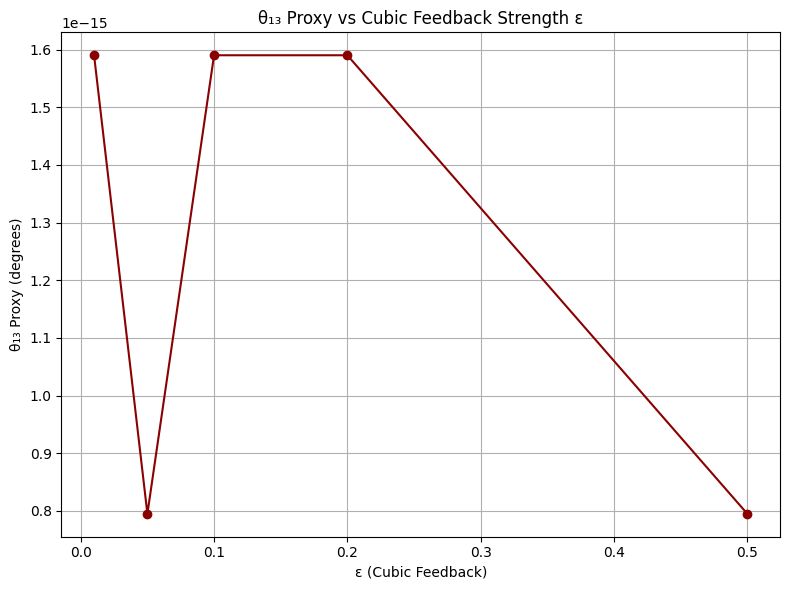

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
kappa = 0.2
delta = 0.02
gamma0 = 0.5
xi = 0.01
A0 = 0.1
time_steps = 100
grid_size = 50
epsilons = [0.01, 0.05, 0.1, 0.2, 0.5]

# -------------------------------
# Curvature Extraction Function
# -------------------------------
def extract_peak_curvature(epsilon):
    A = np.ones(grid_size) * A0
    peak_curvature = 0

    for t in range(time_steps):
        laplacian = np.roll(A, -1) - 2 * A + np.roll(A, 1)
        dA_dt = -kappa * A + delta * A**2 + epsilon * A**3 + gamma0 * laplacian + xi
        A += dA_dt * 0.1

        curvature = np.std(A)
        peak_curvature = max(peak_curvature, curvature)

    return peak_curvature

# -------------------------------
# Run Sweep and Fit θ₁₃ Proxy
# -------------------------------
peak_curvatures = [extract_peak_curvature(eps) for eps in epsilons]
theta13_proxy = [np.degrees(np.arctan(c)) for c in peak_curvatures]

# -------------------------------
# Plot θ₁₃ Proxy vs ε
# -------------------------------
plt.figure(figsize=(8, 6))
plt.plot(epsilons, theta13_proxy, marker='o', color='darkred')
plt.title("θ₁₃ Proxy vs Cubic Feedback Strength ε")
plt.xlabel("ε (Cubic Feedback)")
plt.ylabel("θ₁₃ Proxy (degrees)")
plt.grid(True)
plt.tight_layout()
plt.show()
